# Image Classification - COVID data

**INFO:**

COVID-19, a disease triggered by a specific virus, while viral pneumonia is a condition that can be triggered by a wide range of viruses. COVID-19 is a type of viral pneumonia, but it is only associated with one virus (SARS-CoV-2), whereas viral pneumonia is a broader term that can be caused by many different viruses.

**There are 3 types of images in the data set:** Normal, Covid, and Viral Pneumonia. The Covid ones are specifically caused by the SARS virus, while viral pneumonia may have come from different viruses. These distinctions will be made in the prediction results.


**For Diagnosis:**

Although there are some similarities between COVID-19 and viral pneumonia in X-ray films, COVID-19 typically presents with more widespread and diffuse opacities, whereas viral pneumonia tends to show more focused and localized features.

However, X-ray films alone are not sufficient for a definitive diagnosis. Advanced tests such as PCR testing or CT scans are required for the most accurate diagnosis.

**Environment Setup**

In [1]:
# You can switch to T4 GPU from the very beginning.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# pwd
import os
os.getcwd()

'/content'

In [7]:
%cd /content/drive/MyDrive/B287/CNN/covid_classification

/content/drive/MyDrive/B287/CNN/covid_classification


In [8]:
# Ultralytics download
%pip install ultralytics

import ultralytics
ultralytics.checks()

Ultralytics 8.3.175 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.2/112.6 GB disk)


## Classification - Prediction

In [9]:
# We are using a pre-trained model for image recognition


!yolo classify predict model=yolov8l-cls.pt source="https://images.pexels.com/photos/2253275/pexels-photo-2253275.jpeg" save=True


# To view YOLO's pre-trained models, check out the model list on GitHub at
# [https://github.com/ultralytics/ultralytics](https://github.com/ultralytics/ultralytics).

# The image is from the internet link, and I am saving it using `save=True`.
# Once the code runs, you can go to the `runs` folder to check the results, and it's also saved in the relevant folder in MyDrive under CNN-CV lesson ..........
# The model identified the image as a golden retriever: a golden-colored hunting dog.
# The prediction result image is also available in the corresponding folder in Google Drive.


Ultralytics 8.3.175 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8l-cls summary (fused): 54 layers, 37,465,576 parameters, 0 gradients, 99.7 GFLOPs

Found https://images.pexels.com/photos/2253275/pexels-photo-2253275.jpeg locally at pexels-photo-2253275.jpeg
image 1/1 /content/drive/MyDrive/B287/CNN/covid_classification/pexels-photo-2253275.jpeg: 224x224 golden_retriever 1.00, flat-coated_retriever 0.00, tennis_ball 0.00, Labrador_retriever 0.00, Irish_setter 0.00, 10.9ms
Speed: 170.7ms preprocess, 10.9ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Results saved to runs/classify/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


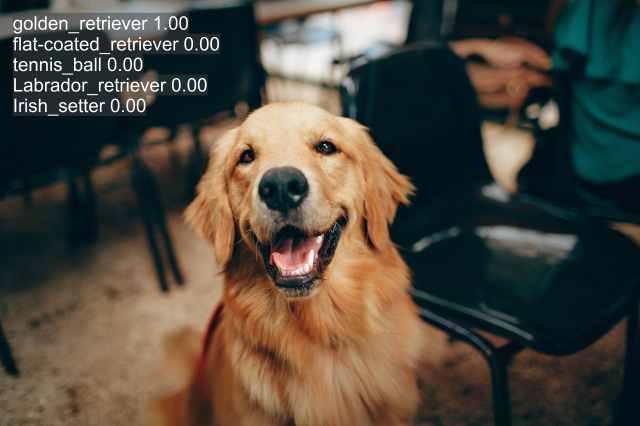

In [10]:
# To examine the results here as well
# According to the new analysis above, the `.pth` part has been changed to `predict4 (5,6)`, so please pay attention to that.

import cv2
from  google.colab.patches import cv2_imshow   # to show the image
import imutils   # to resize the image

img_path="/content/drive/MyDrive/B287/CNN/covid_classification/runs/classify/predict/pexels-photo-2253275.jpg"
img = cv2.imread(img_path)
img=imutils.resize(img,width=640)
cv2_imshow(img)

In [11]:
# The above results were done automatically, but can we obtain these results manually?
# By looking at the path part of the above analysis result file, it was arranged as `predict`.


import numpy as np
from ultralytics import YOLO

img_path = "/content/drive/MyDrive/B287/CNN/covid_classification/pexels-photo-2253275.jpeg"
model_path = "/content/drive/MyDrive/B287/CNN/covid_classification/yolov8l-cls.pt"

model = YOLO(model_path)  # Load the model
results = model(img_path)  # Load the image and classify

# According to YOLO documentation, the following part was written
class_dict = results[0].names
probs = results[0].probs.data.tolist()

print("Classes", class_dict)
print("Probabilities", probs)

print("Result: ", class_dict[np.argmax(probs)])

# Use the cv2.putText() method to write the results on the image / display with cv2_imshow
# The result is written at the bottom: golden_retriever



image 1/1 /content/drive/MyDrive/B287/CNN/covid_classification/pexels-photo-2253275.jpeg: 224x224 golden_retriever 1.00, flat-coated_retriever 0.00, tennis_ball 0.00, Labrador_retriever 0.00, Irish_setter 0.00, 11.0ms
Speed: 134.7ms preprocess, 11.0ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Classes {0: 'tench', 1: 'goldfish', 2: 'great_white_shark', 3: 'tiger_shark', 4: 'hammerhead', 5: 'electric_ray', 6: 'stingray', 7: 'cock', 8: 'hen', 9: 'ostrich', 10: 'brambling', 11: 'goldfinch', 12: 'house_finch', 13: 'junco', 14: 'indigo_bunting', 15: 'robin', 16: 'bulbul', 17: 'jay', 18: 'magpie', 19: 'chickadee', 20: 'water_ouzel', 21: 'kite', 22: 'bald_eagle', 23: 'vulture', 24: 'great_grey_owl', 25: 'European_fire_salamander', 26: 'common_newt', 27: 'eft', 28: 'spotted_salamander', 29: 'axolotl', 30: 'bullfrog', 31: 'tree_frog', 32: 'tailed_frog', 33: 'loggerhead', 34: 'leatherback_turtle', 35: 'mud_turtle', 36: 'terrapin', 37: 'box_turtle', 38: 'banded_gecko', 39: 

## Training

In [12]:
# Extracts RAR files and saves them again into the data folder:
!unzip "/content/drive/MyDrive/B287/CNN/covid_classification/covid_classification.zip" -d ./data
# If you have already extracted the RAR file once, you do not need to do it again.


Streaming output truncated to the last 5000 lines.
  inflating: ./data/covid_classification/train/normal/Normal-7298.png  
  inflating: ./data/covid_classification/train/normal/Normal-7299.png  
  inflating: ./data/covid_classification/train/normal/Normal-73.png  
  inflating: ./data/covid_classification/train/normal/Normal-7300.png  
  inflating: ./data/covid_classification/train/normal/Normal-7301.png  
  inflating: ./data/covid_classification/train/normal/Normal-7302.png  
  inflating: ./data/covid_classification/train/normal/Normal-7303.png  
  inflating: ./data/covid_classification/train/normal/Normal-7304.png  
  inflating: ./data/covid_classification/train/normal/Normal-7305.png  
  inflating: ./data/covid_classification/train/normal/Normal-7306.png  
  inflating: ./data/covid_classification/train/normal/Normal-7309.png  
  inflating: ./data/covid_classification/train/normal/Normal-731.png  
  inflating: ./data/covid_classification/train/normal/Normal-7310.png  
  inflating: ./d

In [13]:
# Model Fitting Part
# Training (According to YOLO documentation, we do `classify`, `train`, and use the yolov8l model?)
# `(device=0` runs CUDA, `workers=` defines the number of parallel working cores)
# `name=.....` part shows where the results will be saved.

!yolo classify train model=yolov8l-cls.pt data=data/covid_classification imgsz=224 workers=8 batch=16 device=0 epochs=25 name="yolov8_classification"

Ultralytics 8.3.175 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/covid_classification, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8l-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8_classification, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12

In [ ]:
# If the YOLO training is interrupted, continue from where it left off (for example, if it is interrupted at epoch 10):**
!yolo classify train model=runs/classify/yolov8_classification2/weights/last.pt resume=True


# If it is interrupted at epoch 10, the training up to that point is saved in `last.pt`, and with this code, it will continue from epoch 10.
# The final weight file will be `best.pt`. The important thing is to correctly specify the path to `last.pt`.

In [ ]:
# In the results section of the code we executed for the above model, it can be seen that the results are saved in `runs/classify/yolov8_classification`.
# The results can also be accessed from the corresponding section in Google Drive (weights, confusion matrix, etc.).
# In the results on Google Drive, the `train` and `loss` graphs show the learning success.
# In the `results` folder on Drive, the images labeled `val_batch` display the prediction results.

## COVID Classification / Prediction

In [15]:
# Image Classification:
# We provide the path to the `best.py` file inside the `weights` folder where the above results are stored.
# For the `source` part, we specify the location of the newly created folder inside the `data` folder
# (called the `inference` folder), where we have copied some covid and non-covid images.
!yolo classify predict model="/content/drive/MyDrive/B287/CNN/covid_classification/runs/classify/yolov8_classification/weights/best.pt" source="/content/drive/MyDrive/B287/CNN/covid_classification/inference" save=True


Ultralytics 8.3.175 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
YOLOv8l-cls summary (fused): 54 layers, 36,188,419 parameters, 0 gradients, 98.7 GFLOPs

image 1/13 /content/drive/MyDrive/B287/CNN/covid_classification/inference/COVID-22.png: 224x224 normal 0.97, covid 0.03, viral_pneumonia 0.00, 15.5ms
image 2/13 /content/drive/MyDrive/B287/CNN/covid_classification/inference/COVID-30.png: 224x224 covid 1.00, normal 0.00, viral_pneumonia 0.00, 12.2ms
image 3/13 /content/drive/MyDrive/B287/CNN/covid_classification/inference/COVID-49.png: 224x224 covid 1.00, normal 0.00, viral_pneumonia 0.00, 14.0ms
image 4/13 /content/drive/MyDrive/B287/CNN/covid_classification/inference/COVID-78.png: 224x224 covid 1.00, normal 0.00, viral_pneumonia 0.00, 11.0ms
image 5/13 /content/drive/MyDrive/B287/CNN/covid_classification/inference/Normal-33.png: 224x224 normal 0.96, covid 0.04, viral_pneumonia 0.00, 11.5ms
image 6/13 /content/drive/MyDrive/B287/CNN/covid_classification/inference/Nor

In [ ]:
# Based on the above prediction results, we can open the images in `results/predict` (or it could be `predict2`, `predict3`, etc.) and check the prediction results.



image 1/1 /content/drive/MyDrive/B287/CNN/covid_classification/inference/COVID-78.png: 224x224 covid 1.00, normal 0.00, viral_pneumonia 0.00, 10.8ms
Speed: 3.9ms preprocess, 10.8ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Classes {0: 'covid', 1: 'normal', 2: 'viral_pneumonia'}
Probabilities [0.9987488985061646, 0.0012496111448854208, 1.4750742138858186e-06]
Result:  covid


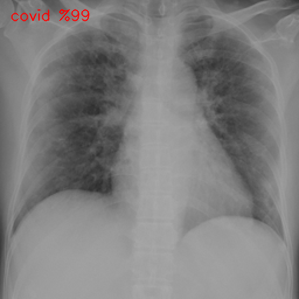

In [16]:
# Let's select any image and check the prediction result:**
import cv2
import numpy as np
from ultralytics import YOLO
from google.colab.patches import cv2_imshow

img_path = "/content/drive/MyDrive/B287/CNN/covid_classification/inference/COVID-78.png"
model_path = "/content/drive/MyDrive/B287/CNN/covid_classification/runs/classify/yolov8_classification/weights/best.pt"

# Load the model
model = YOLO(model_path)
# Load and classify the image
results = model(img_path)

# Get class names and probabilities
class_dict = results[0].names
probs = results[0].probs.data.tolist()

print("Classes", class_dict)
print("Probabilities", probs)

# Print the result with the highest probability
print("Result: ", class_dict[np.argmax(probs)])

# Prepare the result text
name = class_dict[np.argmax(probs)]
max_prob = int(np.max(probs) * 100)

# Prepare the text for the image
text = name + " " + "%" + str(max_prob)

# Display the result on the image
img = cv2.imread(img_path)
cv2.putText(img, text, (10,20), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1, cv2.LINE_AA) # Code to add the prediction result text

cv2_imshow(img)
